# **1. Entendimiento del Problema - Understanding the problem**

Una empresa del sector comercializador de vehículos en Estados Unidos necesita mejorar su proceso de valoración de autos. Por esta razon, busca construir un modelo analítico que permita estimar el precio de los vehículos a partir de características como la marca, modelo, año, color, kilometraje y ubicación.

# **2. Enfoque Analítico - Analitical scope**

Construir un experimento de regresión que permita predecir el precio de cada vehículo buscando un MAPE menor o igual al 15%, de forma que el modelo tenga un nivel de error suficientemente bajo para ser útil en el negocio.

# **3. Requerimiento de Datos - Data requirements**

- Datos de identificación del vehículo.
- Datos de características del vehículo, como marca, modelo, año y color.
- Datos de uso o desgaste del vehículo, como el kilometraje.
- Datos del contexto comercial, como la ubicación.
- Dato objetivo o variable a predecir: precio del vehículo.

# **4. Recolección de Datos - Data collection**

- Car ID: identificador único del vehículo.
- Brand: marca del vehículo.
- Model: modelo del vehículo.
- Year: año de fabricación del vehículo.
- Color: color del vehículo.
- Mileage: kilometraje registrado del vehículo.
- Price: precio del vehículo.
- Location: ciudad o ubicación donde se comercializa el vehículo.

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')
data = pd.read_csv('datos_reg_caso_1.csv')
data.head()

,Car ID,Brand,Model,Year,Color,Mileage,Price,Location
0,1,Toyota,Camry,2018,White,45000,18000,Los Angeles
1,2,Honda,Civic,2019,Blue,35000,16000,New York
2,3,Ford,Focus,2017,Silver,55000,14000,Chicago
3,4,Chevrolet,Cruze,2016,Red,60000,12000,Miami
4,5,Hyundai,Elantra,2018,Black,40000,15000,San Francisco


# **5. Entendimiento de los datos - Data understanding**
- Validación de nulidad
- Comportamiento de variables numéricas para medir sesgos antinaturales.
- Comportamiento de variables categóricas para medir desbalances.
- Medir la correlación para identificar multicolinealidad.
- Identificación de relaciones entre variables.

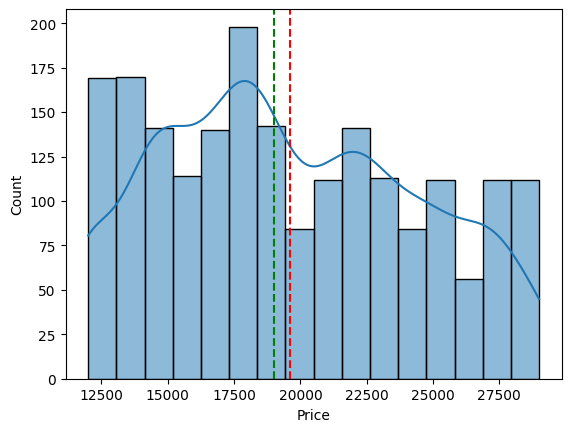

In [2]:
import matplotlib.pyplot as plt
import seaborn as sb
#Identificar la variable y
sb.histplot(data = data, x = 'Price', kde = True)
plt.axvline(x = data.Price.mean(), color = 'red', linestyle = 'dashed')
plt.axvline(x = data.Price.median(), color = 'green', linestyle = 'dashed')
plt.show()

In [3]:
# Eliminar columna identificadora de una vez (no aporta al modelo)
data = data.drop(columns=['Car ID'])

data.head()

,Brand,Model,Year,Color,Mileage,Price,Location
0,Toyota,Camry,2018,White,45000,18000,Los Angeles
1,Honda,Civic,2019,Blue,35000,16000,New York
2,Ford,Focus,2017,Silver,55000,14000,Chicago
3,Chevrolet,Cruze,2016,Red,60000,12000,Miami
4,Hyundai,Elantra,2018,Black,40000,15000,San Francisco


In [4]:
#Datos Nulos
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Brand     2000 non-null   object
 1   Model     2000 non-null   object
 2   Year      2000 non-null   int64 
 3   Color     2000 non-null   object
 4   Mileage   2000 non-null   int64 
 5   Price     2000 non-null   int64 
 6   Location  2000 non-null   object
dtypes: int64(3), object(4)
memory usage: 109.5+ KB


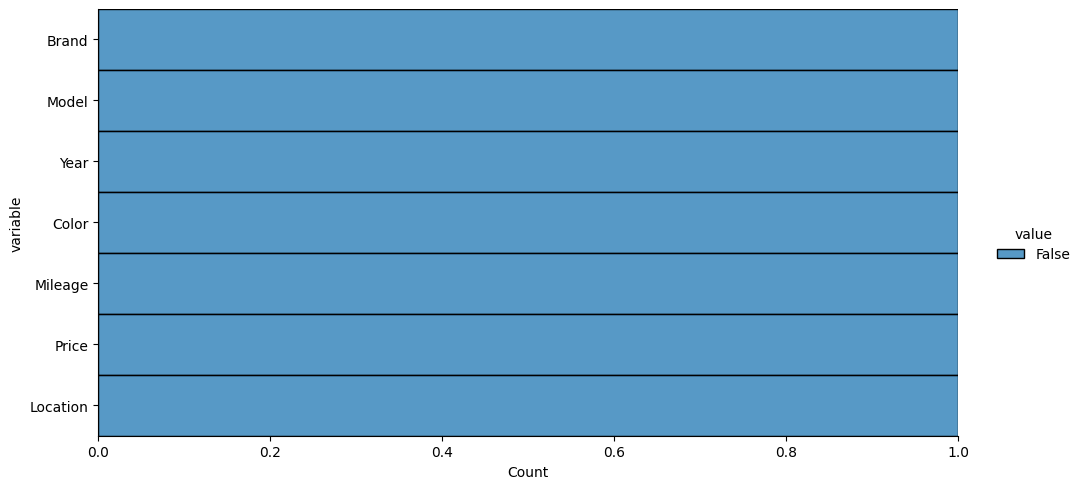

In [5]:
data.isnull().melt().pipe(lambda df: sb.displot(data = df, y = 'variable', hue = 'value', multiple = 'fill', aspect = 2))
plt.show()

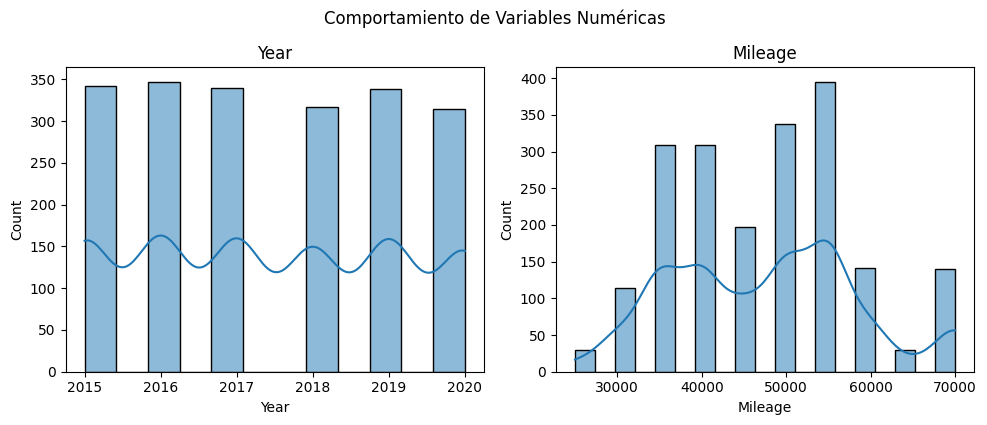

In [6]:
import matplotlib.pyplot as plt
import seaborn as sb

num_col = data.drop(columns=['Price']).select_dtypes(include=['int64', 'float64']).columns

fig, ax = plt.subplots(1, len(num_col), figsize=(5 * len(num_col), 4))

if len(num_col) == 1:
    ax = [ax]

for i, col in enumerate(num_col):
    sb.histplot(data=data, x=col, kde=True, ax=ax[i])
    ax[i].set_title(col)

fig.tight_layout()
fig.suptitle('Comportamiento de Variables Numéricas', y=1.05)
plt.show()

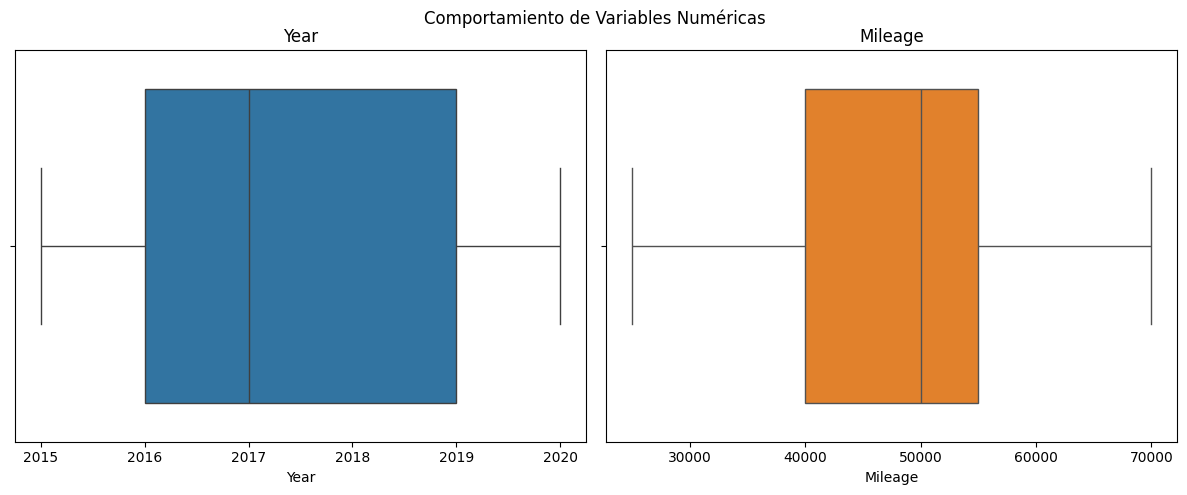

In [7]:
fig, ax = plt.subplots(1, 2, figsize = (12, 5))
ax = ax.flat
num_col = data.drop(columns = 'Price').select_dtypes(include = ['int64', 'float64']).columns
for i, col in enumerate(num_col):
    sb.boxplot(data = data, x = col, 
                color = (list(plt.rcParams['axes.prop_cycle']) * 7)[i]['color'], ax = ax[i])
    ax[i].set_title(col)
fig.tight_layout()
fig.subplots_adjust(top = 0.9)
fig.suptitle('Comportamiento de Variables Numéricas')
plt.show()

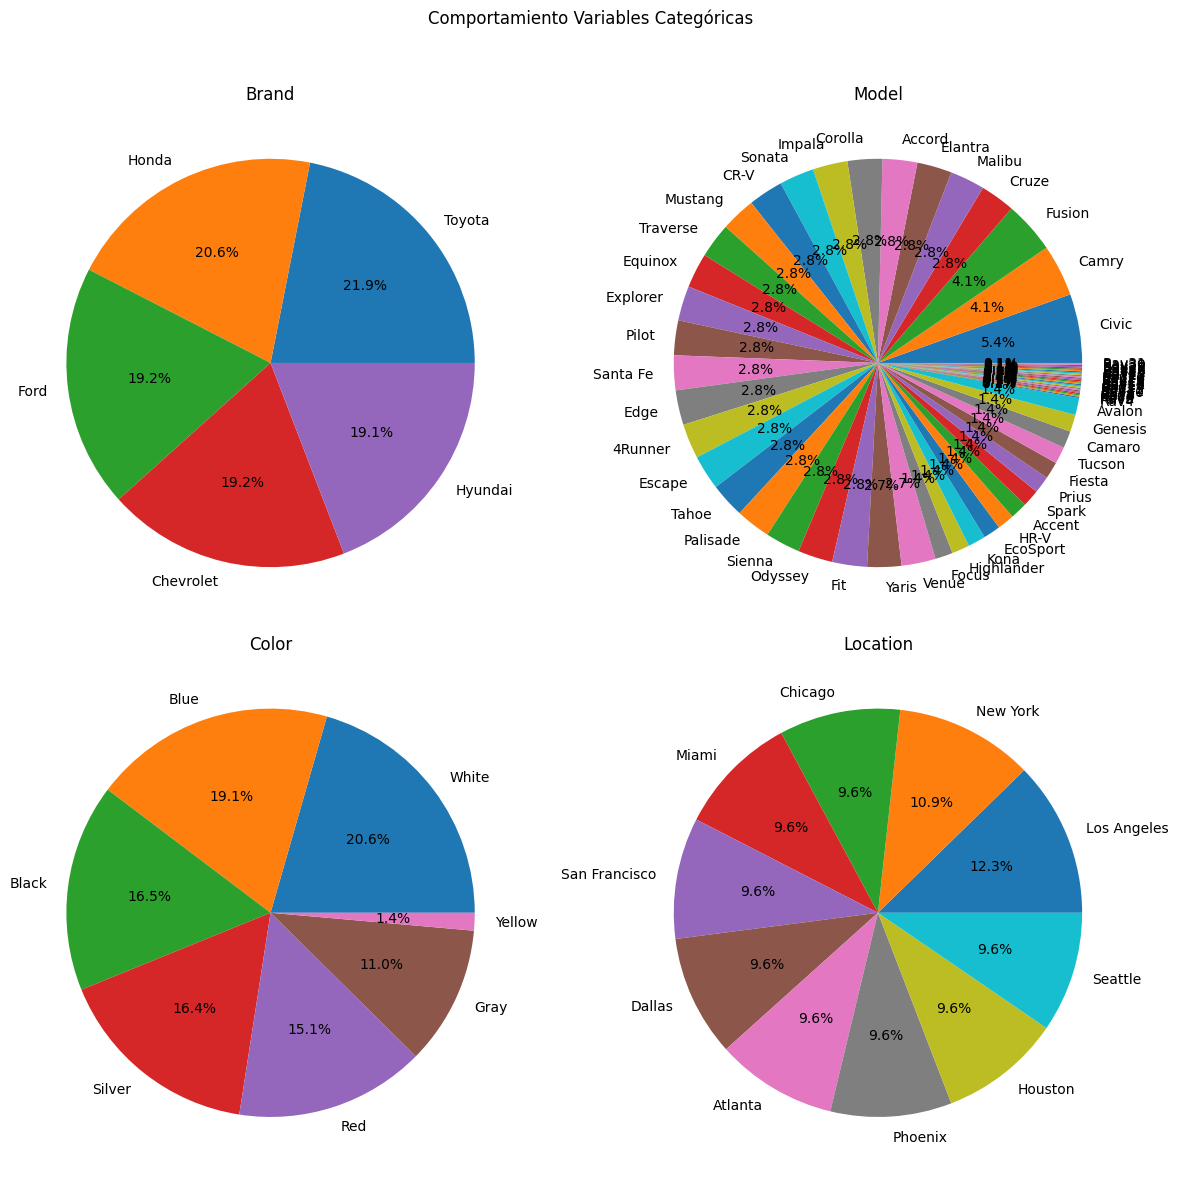

In [8]:
#Gráfico de torta para variables categóricas
fig, ax = plt.subplots(2, 2, figsize = (12, 12))
ax = ax.flat
cat_col = data.select_dtypes(include = ['object']).columns
for i, col in enumerate(cat_col):
    ax[i].pie(x = data[col].value_counts(), labels = data[col].value_counts().index, autopct = '%0.1f%%')
    ax[i].set_title(col)
fig.tight_layout()
fig.subplots_adjust(top = 0.9)
fig.suptitle("Comportamiento Variables Categóricas")
plt.show()

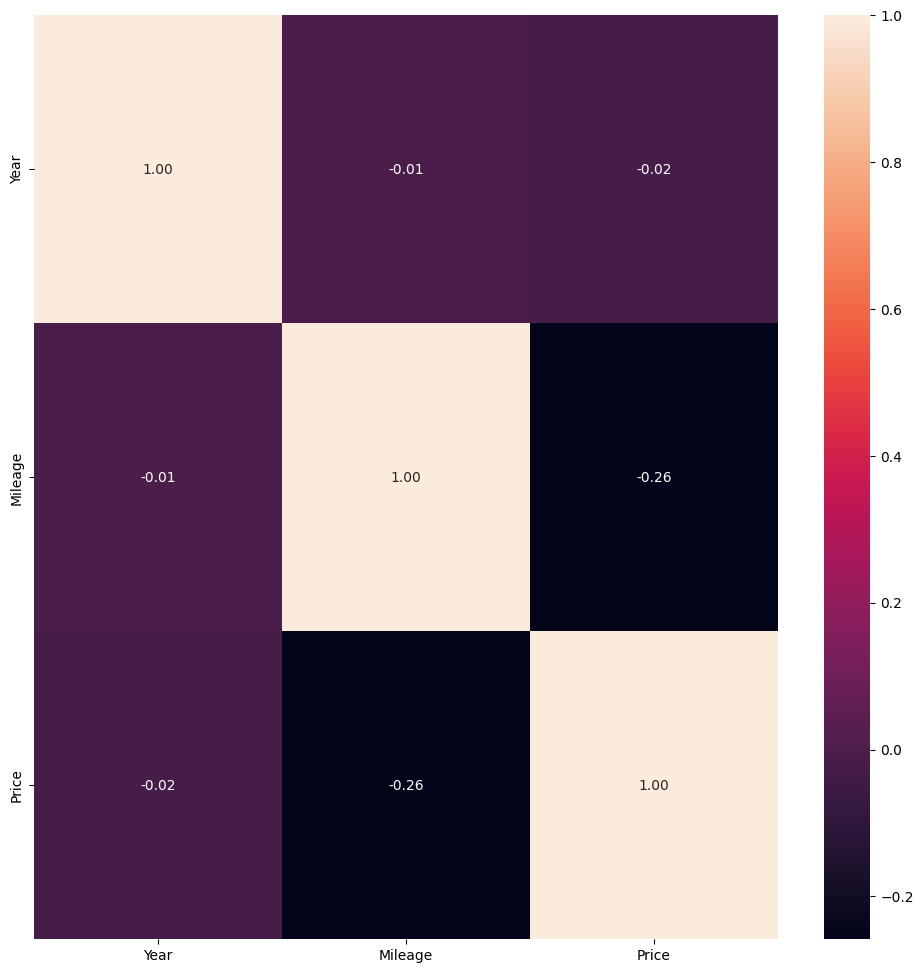

In [9]:
plt.figure(figsize = (12, 12))
sb.heatmap(data.corr(numeric_only = True), annot = True, fmt = '0.2f')
plt.show()

# **6. Preparación de los Datos - Data Preparation**
- Ignorar el indice ya que no aporta nada (ya lo habiamos hecho)
- Escalar variables numéricas y codificar variables categóricas
- Separar en entrenamiento y validación

In [10]:
data['Year'] = data['Year'].astype('object')

data_mod = data

data_mod.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Brand     2000 non-null   object
 1   Model     2000 non-null   object
 2   Year      2000 non-null   object
 3   Color     2000 non-null   object
 4   Mileage   2000 non-null   int64 
 5   Price     2000 non-null   int64 
 6   Location  2000 non-null   object
dtypes: int64(2), object(5)
memory usage: 109.5+ KB


In [11]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler, OrdinalEncoder
from sklearn.pipeline import Pipeline

num_col = data_mod.select_dtypes(include=['int64', 'float64']).columns.to_list()
cat_col = data_mod.select_dtypes(include=['object']).columns.to_list()

num_transformer = Pipeline(steps=[
    ('scaler', MinMaxScaler())
])

cat_transformer = Pipeline(steps=[
    ('encoder', OrdinalEncoder())
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, num_col),
    ('cat', cat_transformer, cat_col)
], remainder='passthrough')

preprocessor

ColumnTransformer(remainder='passthrough',
                  transformers=[('num',
                                 Pipeline(steps=[('scaler', MinMaxScaler())]),
                                 ['Mileage', 'Price']),
                                ('cat',
                                 Pipeline(steps=[('encoder',
                                                  OrdinalEncoder())]),
                                 ['Brand', 'Model', 'Year', 'Color',
                                  'Location'])])

In [12]:
data_pre = preprocessor.fit_transform(data_mod)
cod_cat = preprocessor.named_transformers_['cat']['encoder'].get_feature_names_out(cat_col)
data_pro = pd.DataFrame(data_pre, columns = np.concatenate([num_col, cod_cat]))
data_pro.head()

,Mileage,Price,Brand,Model,Year,Color,Location
0,0.444444,0.352941,4.0,6.0,3.0,5.0,4.0
1,0.222222,0.235294,2.0,7.0,4.0,1.0,6.0
2,0.666667,0.117647,1.0,18.0,2.0,4.0,1.0
3,0.777778,0.000000,0.0,9.0,1.0,3.0,5.0
4,0.333333,0.176471,3.0,12.0,3.0,0.0,8.0


In [13]:
X = data_pro.drop(columns = 'Price')
y = data_pro[['Price']]

In [14]:
from sklearn.model_selection import train_test_split
np.random.seed(20)
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size = 0.7, random_state = 123)
print(f'El tamaño del conjunto de entrenamiento es {X_train.shape} {y_train.shape}\nEl tamaño del conjuunto de validación es {X_test.shape} {y_test.shape}')

El tamaño del conjunto de entrenamiento es (1400, 6) (1400, 1)
El tamaño del conjuunto de validación es (600, 6) (600, 1)


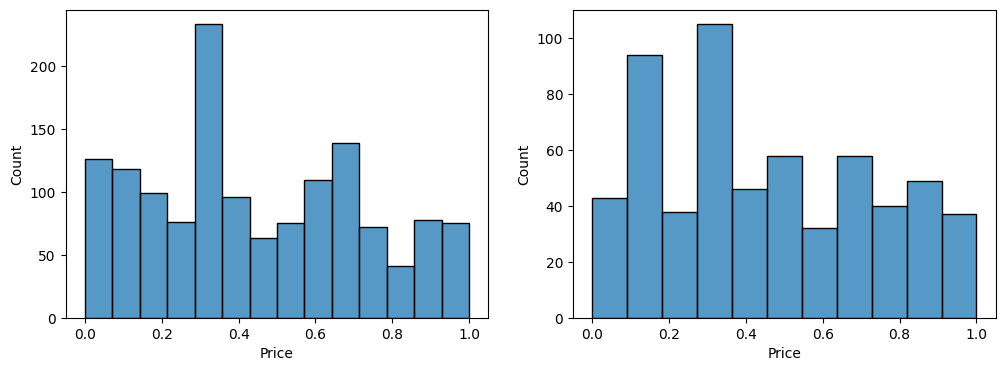

In [15]:
fig, ax = plt.subplots(1, 2, figsize = (12, 4))
sb.histplot(data = y_train, x = 'Price', ax = ax[0])
sb.histplot(data = y_test, x = 'Price', ax = ax[1])
plt.show()

# **7. Modelado de Datos - Data Modeling**

- Regresión Lineal
- K Vecinos Más Cercanos
- Máquina de Soporte Vectorial
- Árboles de Decisión
- Random Frest
- Extra Tree Regressor
- Adaptative Boosting
- Gradient Boosting
- RNA Perceptrón Multicapa

In [16]:
#Regresión Lineal
# Representa el valor predicho como una combinacion lineal
# Con el valor predicho trata de minimizar el error cuadratico o sea sumatoria de (y-ypred)^2

from sklearn.linear_model import LinearRegression
modelo_1 = LinearRegression()
modelo_1.fit(X_train, y_train)

LinearRegression()

In [17]:
modelo_1.coef_

array([[-2.94000918e-01,  2.78095959e-04, -6.93367029e-04,
        -4.98821769e-03, -3.04535179e-03,  3.04604621e-04]])

In [18]:
modelo_1.intercept_

array([0.63120537])

In [19]:
#K Vecinos Más Cercanos
#Promedio de los vecinos mas cercanos
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
np.random.seed(20)
modelo_2 = KNeighborsRegressor()
param_grid = {'n_neighbors':[2, 3, 4, 5, 100, 205, 570], 'p':[1, 2]}
cv = 5
reg_2 = GridSearchCV(estimator = modelo_2, param_grid = param_grid, cv = cv, scoring = 'neg_mean_absolute_error', n_jobs = -1)
reg_2.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=KNeighborsRegressor(), n_jobs=-1,
             param_grid={'n_neighbors': [2, 3, 4, 5, 100, 205, 570],
                         'p': [1, 2]},
             scoring='neg_mean_absolute_error')

In [20]:
validation = pd.concat([pd.DataFrame(reg_2.cv_results_['params']),
                        pd.DataFrame(reg_2.cv_results_['mean_test_score'], columns = ['NEG_MAPE'])], axis = 1)
validation.sort_values('NEG_MAPE', ascending = False)

,n_neighbors,p,NEG_MAPE
10,205,1,-0.237825
8,100,1,-0.238271
9,100,2,-0.238545
11,205,2,-0.238683
12,570,1,-0.238752
13,570,2,-0.238890
6,5,1,-0.253538
7,5,2,-0.253714
4,4,1,-0.253771
5,4,2,-0.253782


In [21]:
#Imaginar una recta de prediccion con un tubo con grosor alrededor. Lo que este en el tubo se considera error aceptable.
# SVR busca que la funcion sea sencilla (coeficientes pequenos) y que muchos puntos queden dentro del tubo.
# C es que tanto se castiga el error (solo se castigan puntos fuera del tubo).
# Los vectores de soporte los puntos que quedan sobre el borde del tubo o los que quedan fuera del tubo ya que estos afectan mas y le dan direccion al tubo
# Como no se obsesiona con cada punto exacto, el modelo puede volverse más “suave” y generalizar mejor en datos nuevos.

from sklearn.svm import SVR
np.random.seed(20)
modelo_3 = SVR()
param_grid = {'C':[0, 0.01, 1, 10, 100], 'kernel':['poly', 'rbf', 'linear'], 'degree':[2, 3]}
cv = 5
reg_3 = GridSearchCV(estimator = modelo_3, param_grid = param_grid, cv = cv, scoring = 'neg_mean_absolute_error', n_jobs = -1)
reg_3.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=SVR(), n_jobs=-1,
             param_grid={'C': [0, 0.01, 1, 10, 100], 'degree': [2, 3],
                         'kernel': ['poly', 'rbf', 'linear']},
             scoring='neg_mean_absolute_error')

In [22]:
validation = pd.concat([pd.DataFrame(reg_3.cv_results_['params']),
                        pd.DataFrame(reg_3.cv_results_['mean_test_score'], columns = ['NEG_MAPE'])], axis = 1)
validation.sort_values('NEG_MAPE', ascending = False)

,C,degree,kernel,NEG_MAPE
8,0.01,2,linear,-0.236599
11,0.01,3,linear,-0.236599
18,10.00,2,poly,-0.236932
12,1.00,2,poly,-0.237068
15,1.00,3,poly,-0.237370
21,10.00,3,poly,-0.237738
19,10.00,2,rbf,-0.238032
22,10.00,3,rbf,-0.238032
27,100.00,3,poly,-0.238201
13,1.00,2,rbf,-0.238393


Profundidad del árbol: 20
Número de hojas: 930


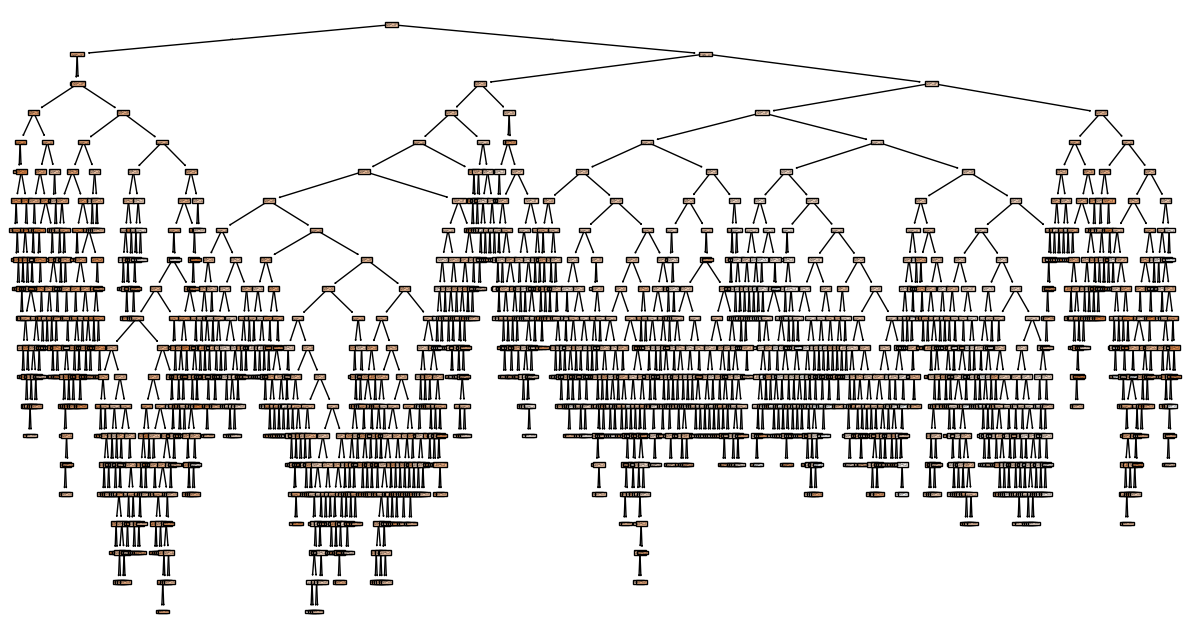

In [23]:
#Árbol de Decisión
from sklearn.tree import DecisionTreeRegressor, plot_tree
tree_model = DecisionTreeRegressor()
tree_model.fit(X_train, y_train)
fig, ax = plt.subplots(figsize = (15, 8))
print(f'Profundidad del árbol: {tree_model.get_depth()}\nNúmero de hojas: {tree_model.get_n_leaves()}')
plot = plot_tree(decision_tree = tree_model, feature_names = np.concatenate([num_col, cod_cat]), filled = True, impurity = False, ax = ax)

In [24]:
np.random.seed(20)
modelo_4 = DecisionTreeRegressor(random_state = 123)
param_grid = {'criterion':['squared_error', 'friedman_mse', 'absolte_error', 'poisson'], 'max_depth':[None, 5, 10, 15, 20, 23, 25, 28], 'max_leaf_nodes':[None, 10, 20, 50, 100], 'min_samples_split':[2, 3, 4, 5]}
cv = 5
reg_4 = GridSearchCV(estimator = modelo_4, param_grid = param_grid, cv = cv, scoring = 'neg_mean_absolute_error', n_jobs = -1)
reg_4.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeRegressor(random_state=123), n_jobs=-1,
             param_grid={'criterion': ['squared_error', 'friedman_mse',
                                       'absolte_error', 'poisson'],
                         'max_depth': [None, 5, 10, 15, 20, 23, 25, 28],
                         'max_leaf_nodes': [None, 10, 20, 50, 100],
                         'min_samples_split': [2, 3, 4, 5]},
             scoring='neg_mean_absolute_error')

In [25]:
validation = pd.concat([pd.DataFrame(reg_4.cv_results_['params']),
                        pd.DataFrame(reg_4.cv_results_['mean_test_score'], columns = ['NEG_MAPE'])], axis = 1)
validation.sort_values('NEG_MAPE', ascending = False)

,criterion,max_depth,max_leaf_nodes,min_samples_split,NEG_MAPE
24,squared_error,5.0,10.0,2,-0.225547
25,squared_error,5.0,10.0,3,-0.225547
26,squared_error,5.0,10.0,4,-0.225547
27,squared_error,5.0,10.0,5,-0.225547
185,friedman_mse,5.0,10.0,3,-0.225547
...,...,...,...,...,...
475,absolte_error,28.0,50.0,5,NaN
476,absolte_error,28.0,100.0,2,NaN
477,absolte_error,28.0,100.0,3,NaN
478,absolte_error,28.0,100.0,4,NaN


In [26]:
#Random Forest
from sklearn.ensemble import RandomForestRegressor
np.random.seed(20)
modelo_5 = RandomForestRegressor(random_state = 123)
param_grid = {'criterion':['squared_error', 'friedman_mse', 'absolte_error', 'poisson'], 'max_depth':[None, 5, 10, 15, 20, 23], 'max_leaf_nodes':[None, 10, 20, 50], 'min_samples_split':[2, 3, 4], 'n_estimators':[100, 200, 300]}
cv = 5
reg_5 = GridSearchCV(estimator = modelo_5, param_grid = param_grid, cv = cv, scoring = 'neg_mean_absolute_error', n_jobs = -1)
reg_5.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=123), n_jobs=-1,
             param_grid={'criterion': ['squared_error', 'friedman_mse',
                                       'absolte_error', 'poisson'],
                         'max_depth': [None, 5, 10, 15, 20, 23],
                         'max_leaf_nodes': [None, 10, 20, 50],
                         'min_samples_split': [2, 3, 4],
                         'n_estimators': [100, 200, 300]},
             scoring='neg_mean_absolute_error')

In [27]:
validation = pd.concat([pd.DataFrame(reg_5.cv_results_['params']),
                        pd.DataFrame(reg_5.cv_results_['mean_test_score'], columns = ['NEG_MAPE'])], axis = 1)
validation.sort_values('NEG_MAPE', ascending = False)

,criterion,max_depth,max_leaf_nodes,min_samples_split,n_estimators,NEG_MAPE
743,poisson,10.0,20.0,3,300,-0.227450
740,poisson,10.0,20.0,2,300,-0.227452
746,poisson,10.0,20.0,4,300,-0.227468
779,poisson,15.0,20.0,3,300,-0.227469
815,poisson,20.0,20.0,3,300,-0.227469
...,...,...,...,...,...,...
643,absolte_error,23.0,50.0,3,200,NaN
644,absolte_error,23.0,50.0,3,300,NaN
645,absolte_error,23.0,50.0,4,100,NaN
646,absolte_error,23.0,50.0,4,200,NaN


In [28]:
#Extra Tree Regressor
from sklearn.ensemble import ExtraTreesRegressor
np.random.seed(20)
modelo_6 = ExtraTreesRegressor(random_state = 123)
param_grid = {'criterion':['squared_error', 'friedman_mse', 'absolte_error', 'poisson'], 'max_depth':[None, 5, 10, 15, 20, 23], 'max_leaf_nodes':[None, 10, 20, 50], 'min_samples_split':[2, 3, 4], 'n_estimators':[100, 200, 300]}
cv = 5
reg_6 = GridSearchCV(estimator = modelo_6, param_grid = param_grid, cv = cv, scoring = 'neg_mean_absolute_error', n_jobs = -1)
reg_6.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=ExtraTreesRegressor(random_state=123), n_jobs=-1,
             param_grid={'criterion': ['squared_error', 'friedman_mse',
                                       'absolte_error', 'poisson'],
                         'max_depth': [None, 5, 10, 15, 20, 23],
                         'max_leaf_nodes': [None, 10, 20, 50],
                         'min_samples_split': [2, 3, 4],
                         'n_estimators': [100, 200, 300]},
             scoring='neg_mean_absolute_error')

In [29]:
validation = pd.concat([pd.DataFrame(reg_6.cv_results_['params']),
                        pd.DataFrame(reg_6.cv_results_['mean_test_score'], columns = ['NEG_MAPE'])], axis = 1)
validation.sort_values('NEG_MAPE', ascending = False)

,criterion,max_depth,max_leaf_nodes,min_samples_split,n_estimators,NEG_MAPE
782,poisson,15.0,20.0,4,300,-0.225747
674,poisson,NaN,20.0,4,300,-0.225747
818,poisson,20.0,20.0,4,300,-0.225747
854,poisson,23.0,20.0,4,300,-0.225747
816,poisson,20.0,20.0,4,100,-0.225769
...,...,...,...,...,...,...
643,absolte_error,23.0,50.0,3,200,NaN
644,absolte_error,23.0,50.0,3,300,NaN
645,absolte_error,23.0,50.0,4,100,NaN
646,absolte_error,23.0,50.0,4,200,NaN


In [30]:
#Adaptative Boosting Regressor
from sklearn.ensemble import AdaBoostRegressor
modelo_7 = AdaBoostRegressor(random_state = 123)
np.random.seed(20)
param_grid = {'n_estimators':[100, 200, 300, 400], 'learning_rate':[0.01, 0.1, 1, 10, 100]}
cv = 5
reg_7 = GridSearchCV(estimator = modelo_7, param_grid = param_grid, cv = cv, scoring = 'neg_mean_absolute_error', n_jobs = -1)
reg_7.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=AdaBoostRegressor(random_state=123), n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.1, 1, 10, 100],
                         'n_estimators': [100, 200, 300, 400]},
             scoring='neg_mean_absolute_error')

In [31]:
validation = pd.concat([pd.DataFrame(reg_7.cv_results_['params']),
                        pd.DataFrame(reg_7.cv_results_['mean_test_score'], columns = ['NEG_MAPE'])], axis = 1)
validation.sort_values('NEG_MAPE', ascending = False) 

,learning_rate,n_estimators,NEG_MAPE
0,0.01,100,-0.226224
1,0.01,200,-0.226880
2,0.01,300,-0.226971
3,0.01,400,-0.226978
5,0.10,200,-0.227893
6,0.10,300,-0.227893
7,0.10,400,-0.227893
4,0.10,100,-0.227897
8,1.00,100,-0.229756
9,1.00,200,-0.229756


In [32]:
#Gradient Boosting Regressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import RandomizedSearchCV
modelo_8 = GradientBoostingRegressor(random_state = 123)
np.random.seed(20)
param_grid = {'criterion':['friedman_mse', 'squared_error'], 'max_depth':[5, 7, 9, 12],
              'max_leaf_nodes':[10, 40, None], 'min_samples_split':[2, 3], 'n_estimators':[100, 200, 300, 400],
              'loss':['squared_error', 'absolute_error', 'huber', 'quantile']}
cv = 5
reg_8 = RandomizedSearchCV(estimator = modelo_8, param_distributions = param_grid, cv = cv, scoring = 'neg_mean_absolute_error', n_iter = 76, n_jobs = -1)
reg_8.fit(X_train, y_train)

RandomizedSearchCV(cv=5, estimator=GradientBoostingRegressor(random_state=123),
                   n_iter=76, n_jobs=-1,
                   param_distributions={'criterion': ['friedman_mse',
                                                      'squared_error'],
                                        'loss': ['squared_error',
                                                 'absolute_error', 'huber',
                                                 'quantile'],
                                        'max_depth': [5, 7, 9, 12],
                                        'max_leaf_nodes': [10, 40, None],
                                        'min_samples_split': [2, 3],
                                        'n_estimators': [100, 200, 300, 400]},
                   scoring='neg_mean_absolute_error')

In [33]:
validation = pd.concat([pd.DataFrame(reg_8.cv_results_['params']),
                        pd.DataFrame(reg_8.cv_results_['mean_test_score'], columns = ['NEG_MAPE'])], axis = 1)
validation.sort_values('NEG_MAPE', ascending = False)

,n_estimators,min_samples_split,max_leaf_nodes,max_depth,loss,criterion,NEG_MAPE
2,100,2,10.0,7,absolute_error,squared_error,-0.225427
30,100,2,10.0,7,absolute_error,friedman_mse,-0.226089
61,100,3,10.0,12,absolute_error,friedman_mse,-0.226258
73,200,2,10.0,7,absolute_error,squared_error,-0.227477
51,200,3,10.0,9,absolute_error,squared_error,-0.227977
...,...,...,...,...,...,...,...
56,300,2,10.0,5,quantile,friedman_mse,-0.345297
10,300,3,10.0,7,quantile,squared_error,-0.346286
42,300,3,10.0,12,quantile,squared_error,-0.346286
46,200,2,10.0,7,quantile,squared_error,-0.346286


In [34]:
#MLP Regressor
from sklearn.neural_network import MLPRegressor
modelo_9 = MLPRegressor(random_state = 123)
np.random.seed(20)
param_grid = {'hidden_layer_sizes':[(10,), (20,), (30,), (30, 20), (20, 10), (30, 20, 10)],
              'activation':['relu', 'logistic', 'tanh'], 'solver':['lbfgs', 'sgd', 'adam'], 
              'learning_rate_init':[0.001, 0.1, 1, 10, 100], 'max_iter':[100, 200, 500]}
cv = 5
reg_9 = RandomizedSearchCV(estimator = modelo_9, param_distributions = param_grid, cv = cv, scoring = 'neg_mean_absolute_error', n_iter = 160, n_jobs = -1)
reg_9.fit(X_train, y_train)

RandomizedSearchCV(cv=5, estimator=MLPRegressor(random_state=123), n_iter=160,
                   n_jobs=-1,
                   param_distributions={'activation': ['relu', 'logistic',
                                                       'tanh'],
                                        'hidden_layer_sizes': [(10,), (20,),
                                                               (30,), (30, 20),
                                                               (20, 10),
                                                               (30, 20, 10)],
                                        'learning_rate_init': [0.001, 0.1, 1,
                                                               10, 100],
                                        'max_iter': [100, 200, 500],
                                        'solver': ['lbfgs', 'sgd', 'adam']},
                   scoring='neg_mean_absolute_error')

In [35]:
validation = pd.concat([pd.DataFrame(reg_9.cv_results_['params']),
                        pd.DataFrame(reg_9.cv_results_['mean_test_score'], columns = ['NEG_MAPE'])], axis = 1)
validation.sort_values('NEG_MAPE', ascending = False)

,solver,max_iter,learning_rate_init,hidden_layer_sizes,activation,NEG_MAPE
133,lbfgs,100,0.1,"(10,)",relu,-0.236450
64,lbfgs,100,100.0,"(10,)",relu,-0.236450
77,lbfgs,100,1.0,"(10,)",relu,-0.236450
34,adam,200,0.1,"(10,)",relu,-0.237573
59,lbfgs,200,1.0,"(30, 20)",logistic,-0.237578
...,...,...,...,...,...,...
102,sgd,100,0.1,"(30, 20, 10)",relu,NaN
132,sgd,500,100.0,"(30,)",logistic,NaN
134,sgd,500,100.0,"(30,)",tanh,NaN
142,sgd,100,100.0,"(20, 10)",logistic,NaN


In [36]:
from sklearn.linear_model import Lars
from sklearn.model_selection import RandomizedSearchCV
import pandas as pd
import numpy as np

# Least Angle Regressor
modelo_lars = Lars()

np.random.seed(20)

param_grid = {
    'n_nonzero_coefs': [1,2,3,4,5,6,7], 'fit_intercept': [True, False], 'jitter': [None, 0.0001, 0.001, 0.01, 0.1]}


reg_lars = RandomizedSearchCV(
    estimator=modelo_lars,
    param_distributions=param_grid,
    cv=5,
    scoring='neg_mean_absolute_error',
    n_iter=20,
    n_jobs=-1,
    random_state=123
)

reg_lars.fit(X_train, y_train)

RandomizedSearchCV(cv=5, estimator=Lars(), n_iter=20, n_jobs=-1,
                   param_distributions={'fit_intercept': [True, False],
                                        'jitter': [None, 0.0001, 0.001, 0.01,
                                                   0.1],
                                        'n_nonzero_coefs': [1, 2, 3, 4, 5, 6,
                                                            7]},
                   random_state=123, scoring='neg_mean_absolute_error')

In [37]:
validation_lars = pd.concat([
    pd.DataFrame(reg_lars.cv_results_['params']),
    pd.DataFrame(reg_lars.cv_results_['mean_test_score'], columns=['NEG_MAPE'])
], axis=1)

validation_lars.sort_values('NEG_MAPE', ascending=False)

,n_nonzero_coefs,jitter,fit_intercept,NEG_MAPE
19,7,NaN,True,-0.237761
9,2,NaN,True,-0.238036
2,6,NaN,False,-0.264771
1,3,NaN,False,-0.283918
0,2,0.0001,True,NaN
3,5,0.1000,False,NaN
4,3,0.0100,True,NaN
5,2,0.0010,False,NaN
6,3,0.0001,True,NaN
7,2,0.0001,False,NaN


## **Evaluación de Modelos - Model Evaluation**
- R2, MAE, RMSE, MAPE
- Validación visual

In [38]:
#Mejores estimadores
modelo_lr = modelo_1
modelo_knn = reg_2.best_estimator_
modelo_svr = reg_3.best_estimator_
modelo_dt = reg_4.best_estimator_
modelo_rf = reg_5.best_estimator_
modelo_et = reg_6.best_estimator_
modelo_ab = reg_7.best_estimator_
modelo_gb = reg_8.best_estimator_
modelo_rna = reg_9.best_estimator_
modelo_lars = reg_lars.best_estimator_

In [39]:
#Predicciones en el conjunto de prueba
y_pred_lr = pd.DataFrame(modelo_lr.predict(X_test), columns = ['Price'])
y_pred_knn = pd.DataFrame(modelo_knn.predict(X_test), columns = ['Price'])
y_pred_svr = pd.DataFrame(modelo_svr.predict(X_test), columns = ['Price'])
y_pred_dt = pd.DataFrame(modelo_dt.predict(X_test), columns = ['Price'])
y_pred_et = pd.DataFrame(modelo_et.predict(X_test), columns = ['Price'])
y_pred_ab = pd.DataFrame(modelo_ab.predict(X_test), columns = ['Price'])
y_pred_gb = pd.DataFrame(modelo_gb.predict(X_test), columns = ['Price'])
y_pred_rna = pd.DataFrame(modelo_rna.predict(X_test), columns = ['Price'])
y_pred_rf = pd.DataFrame(modelo_rf.predict(X_test), columns = ['Price'])
y_pred_lars = pd.DataFrame(modelo_lars.predict(X_test), columns = ['Price'])

In [40]:
#Función para construir estimaciones
def evaluacion_metricas(reales, predicciones):
    from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error, mean_absolute_percentage_error
    import seaborn as sb
    reales_mape = reales * (data.Price.max() - data.Price.min()) + data.Price.min()
    predicciones_mape = predicciones * (data.Price.max() - data.Price.min()) + data.Price.min()
    print(f'Las métricas de desempeño para el modelo son:\nR2: {r2_score(reales, predicciones)}\nRMSE: {root_mean_squared_error(reales, predicciones)}\nMAE: {mean_absolute_error(reales, predicciones)}\nMAPE: {mean_absolute_percentage_error(reales_mape, predicciones_mape)}')
    print('-----------------------')
    print('Gráfico de predicciones')
    sb.histplot(data = reales, x = 'Price', color = 'cyan')
    sb.histplot(data = predicciones, x = 'Price', color = 'magenta')
    plt.legend()
    plt.show()

Las métricas de desempeño para el modelo son:
R2: 0.06969049530093185
RMSE: 0.2713834132787535
MAE: 0.2350648608425458
MAPE: 0.21638690183290635
-----------------------
Gráfico de predicciones


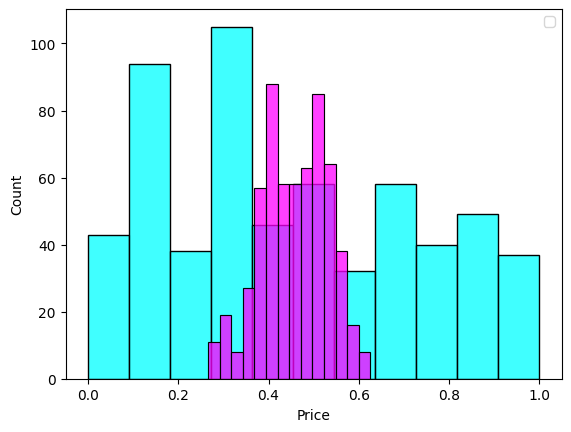

In [41]:
#Regresión Lineal
evaluacion_metricas(y_test, y_pred_lr)

Las métricas de desempeño para el modelo son:
R2: 0.002539582963774545
RMSE: 0.2810071734399943
MAE: 0.23853706360593022
MAPE: 0.2184399474441652
-----------------------
Gráfico de predicciones


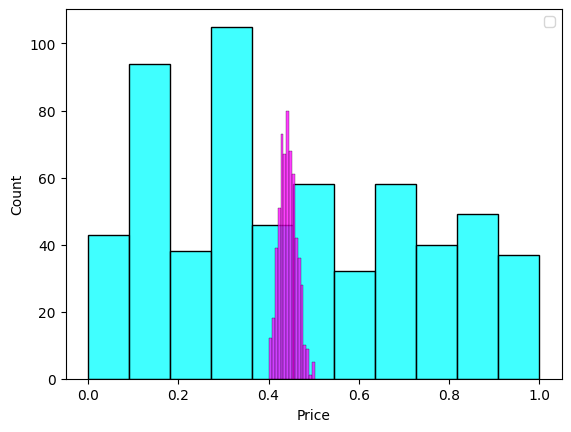

In [42]:
#K Vecinos Más cercanos
evaluacion_metricas(y_test, y_pred_knn)

Las métricas de desempeño para el modelo son:
R2: 0.04358442814155272
RMSE: 0.2751648088206147
MAE: 0.23462870440775271
MAPE: 0.2114392124149405
-----------------------
Gráfico de predicciones


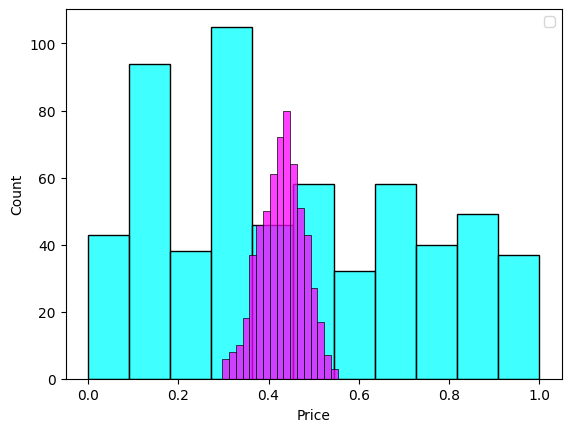

In [43]:
#Máquina de Soporte Vectorial
evaluacion_metricas(y_test, y_pred_svr)

Las métricas de desempeño para el modelo son:
R2: 0.22262289580862604
RMSE: 0.24807639608706994
MAE: 0.21673604664744525
MAPE: 0.19970841438104334
-----------------------
Gráfico de predicciones


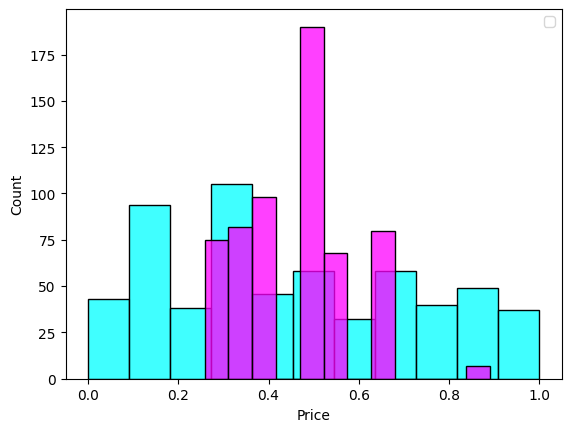

In [44]:
#Árbol de Decisión
evaluacion_metricas(y_test, y_pred_dt)

Las métricas de desempeño para el modelo son:
R2: 0.2232697989324307
RMSE: 0.24797315481896146
MAE: 0.21760170348808647
MAPE: 0.20072546710924571
-----------------------
Gráfico de predicciones


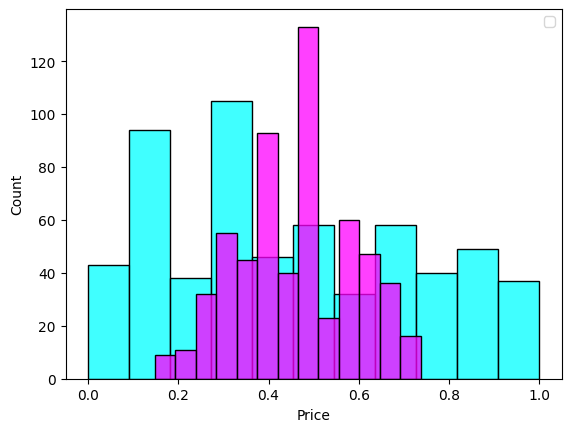

In [45]:
#Bosque Aleatorio
evaluacion_metricas(y_test, y_pred_rf)

Las métricas de desempeño para el modelo son:
R2: 0.23688031322680536
RMSE: 0.24579095679577967
MAE: 0.21713272987297919
MAPE: 0.19994098264855495
-----------------------
Gráfico de predicciones


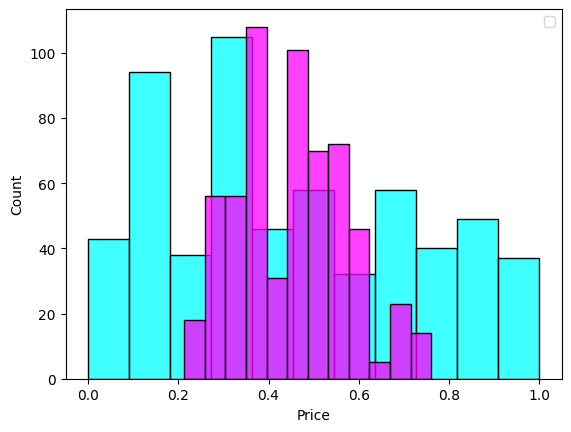

In [46]:
#Extra Trees
evaluacion_metricas(y_test, y_pred_et)

Las métricas de desempeño para el modelo son:
R2: 0.22126884000226377
RMSE: 0.24829235507022498
MAE: 0.21747927518591686
MAPE: 0.2008686762708419
-----------------------
Gráfico de predicciones


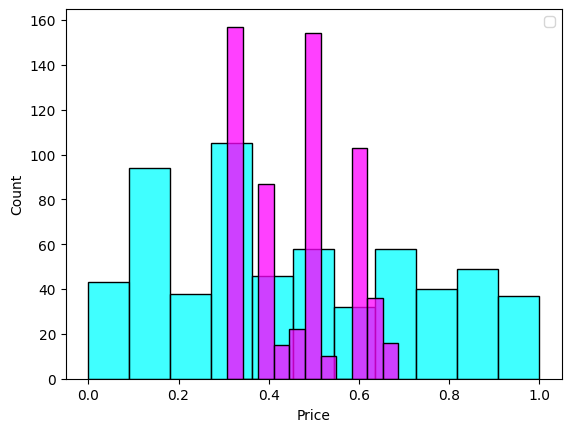

In [47]:
#AdaBoost
evaluacion_metricas(y_test, y_pred_ab)

Las métricas de desempeño para el modelo son:
R2: 0.1245665946083554
RMSE: 0.26325772793131264
MAE: 0.21846689447868112
MAPE: 0.19699475644783263
-----------------------
Gráfico de predicciones


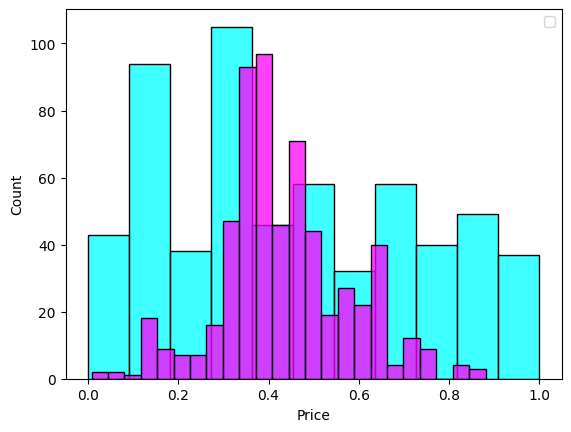

In [48]:
#Gradient Boosting
evaluacion_metricas(y_test, y_pred_gb)

Las métricas de desempeño para el modelo son:
R2: 0.05668497960749386
RMSE: 0.27327376878005477
MAE: 0.23641061735243435
MAPE: 0.21645112967301594
-----------------------
Gráfico de predicciones


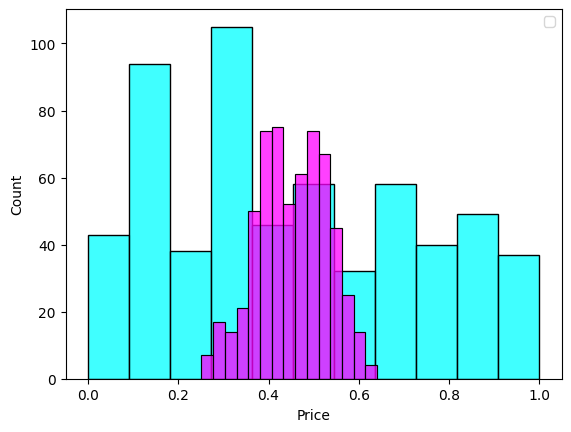

In [49]:
#Red Neuronal Artificial
evaluacion_metricas(y_test, y_pred_rna)

Las métricas de desempeño para el modelo son:
R2: 0.06969049530093185
RMSE: 0.2713834132787535
MAE: 0.2350648608425458
MAPE: 0.21638690183290635
-----------------------
Gráfico de predicciones


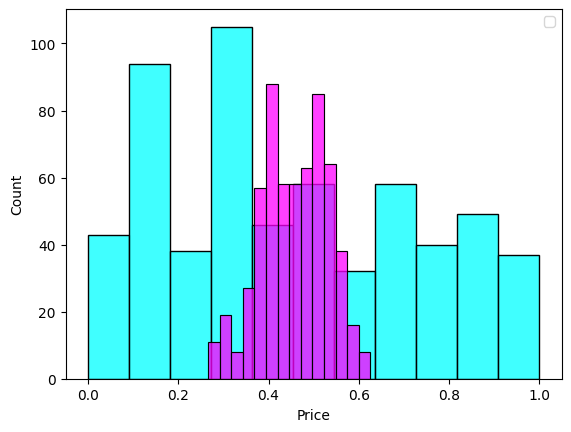

In [50]:
evaluacion_metricas(y_test, y_pred_lars)

In [51]:
def analisis_residuales(df_real, df_pred):
    import pandas as pd
    import matplotlib.pyplot as plt
    from scipy import stats

    y_real = df_real.iloc[:, 0].reset_index(drop = True)
    y_pred = df_pred.iloc[:, 0].reset_index(drop = True)
    residuales = y_real - y_pred

    df_residuales = pd.DataFrame({'real': y_real, 'predicho': y_pred, 'residual': residuales})

    #Identificación de la función de probabilidad de los residuales
    print('Determinación de FDP de los Residuales')
    print('Media de los residuales:', residuales.mean())
    print('Desviación Estándar de los Residuales', residuales.std())
    print('Máximo residual:', residuales.max())
    print('Mínimo residual:', residuales.min())

    plt.figure(figsize = (6, 4))
    plt.hist(residuales, bins = 20, edgecolor = 'black')
    plt.xlabel('Residuales')
    plt.ylabel('Frecuencia')
    plt.title('Histograma de los Residuales')
    plt.show()

    #Identificación de patrones de homocedasticidad
    plt.figure(figsize = (6, 4))
    plt.scatter(y_pred, residuales)
    plt.axhline(0, linestyle = '--')
    plt.xlabel('Predicciones')
    plt.ylabel('Residuales')
    plt.title('Residuales VS Predicciones')
    plt.show()

    #Q-Q Plot
    plt.figure(figsize = (6, 4))
    stats.probplot(residuales, dist = 'norm', plot = plt)
    plt.title('Q-Q Plot de los Residuales')
    plt.show()

    return df_residuales

Determinación de FDP de los Residuales
Media de los residuales: -0.005774751976728196
Desviación Estándar de los Residuales 0.2481127518821906
Máximo residual: 0.6167972531222351
Mínimo residual: -0.5338510824918608


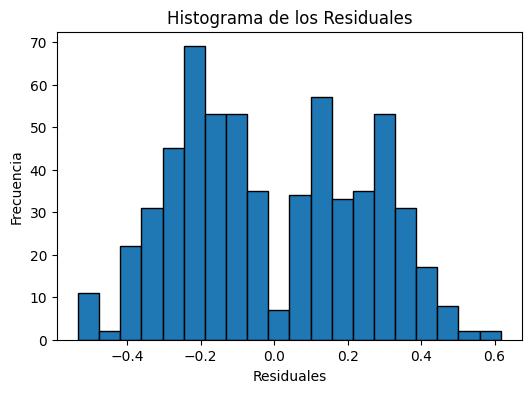

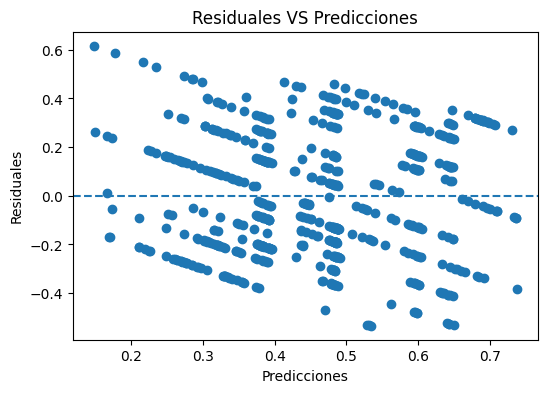

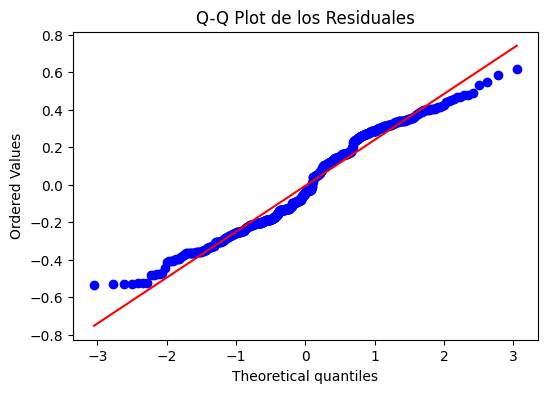

,real,predicho,residual
0,1.000000,0.707040,0.292960
1,0.941176,0.518096,0.423081
2,0.235294,0.439073,-0.203779
3,0.470588,0.529222,-0.058633
4,0.352941,0.376256,-0.023315
...,...,...,...
595,0.176471,0.381219,-0.204749
596,0.588235,0.312749,0.275486
597,0.352941,0.598364,-0.245423
598,0.588235,0.328116,0.260119


In [52]:
#Media 0 y estandar menor a uno es que tiene cara de ruido blanco.
analisis_residuales(y_test,y_pred_rf)

Determinación de FDP de los Residuales
Media de los residuales: 0.01934278211199895
Desviación Estándar de los Residuales 0.2627652260779276
Máximo residual: 0.6855691529574671
Mínimo residual: -0.5440872320551999


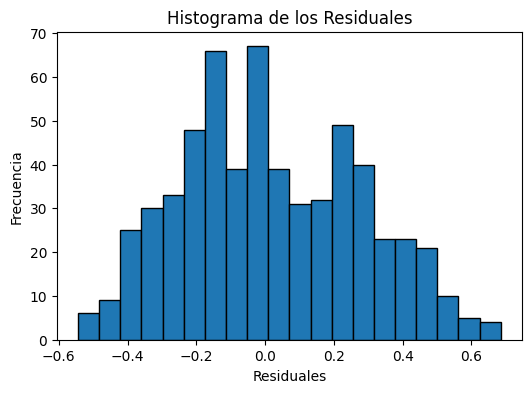

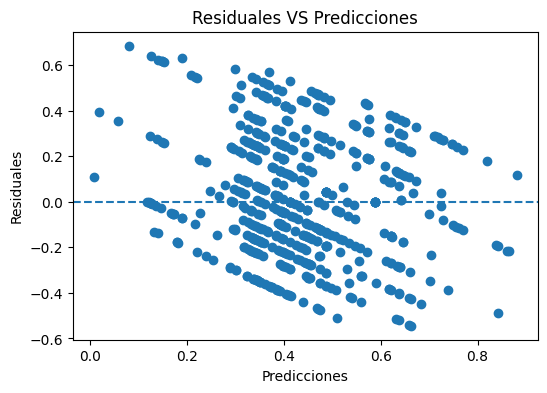

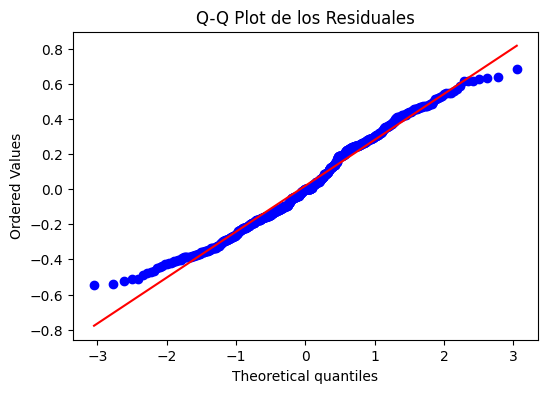

,real,predicho,residual
0,1.000000,0.650430,0.349570
1,0.941176,0.455310,0.485866
2,0.235294,0.340303,-0.105009
3,0.470588,0.509384,-0.038796
4,0.352941,0.296505,0.056436
...,...,...,...
595,0.176471,0.344395,-0.167925
596,0.588235,0.395698,0.192537
597,0.352941,0.620971,-0.268030
598,0.588235,0.330026,0.258210


In [53]:
analisis_residuales(y_test,y_pred_gb)

Determinación de FDP de los Residuales
Media de los residuales: 0.0019107754942177492
Desviación Estándar de los Residuales 0.27349509609176287
Máximo residual: 0.6734144673592537
Mínimo residual: -0.45234434461253814


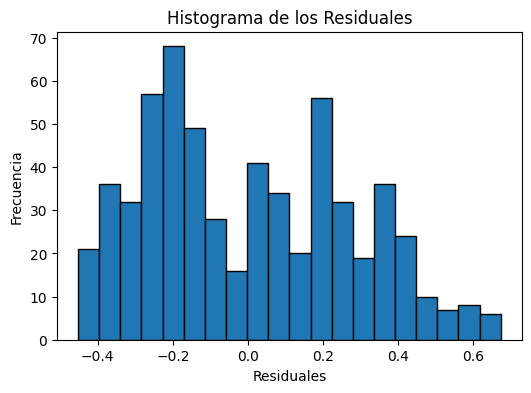

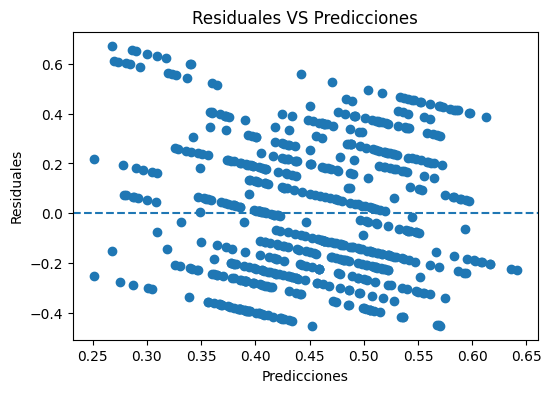

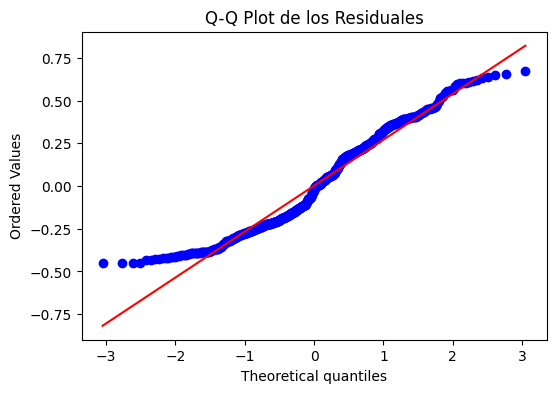

,real,predicho,residual
0,1.000000,0.568953,0.431047
1,0.941176,0.317952,0.623224
2,0.235294,0.419259,-0.183965
3,0.470588,0.251127,0.219461
4,0.352941,0.423027,-0.070085
...,...,...,...
595,0.176471,0.413500,-0.237029
596,0.588235,0.409203,0.179032
597,0.352941,0.522293,-0.169352
598,0.588235,0.391390,0.196845


In [54]:
analisis_residuales(y_test,y_pred_rna)

Determinación de FDP de los Residuales
Media de los residuales: 0.0019107754942177492
Desviación Estándar de los Residuales 0.27349509609176287
Máximo residual: 0.6734144673592537
Mínimo residual: -0.45234434461253814


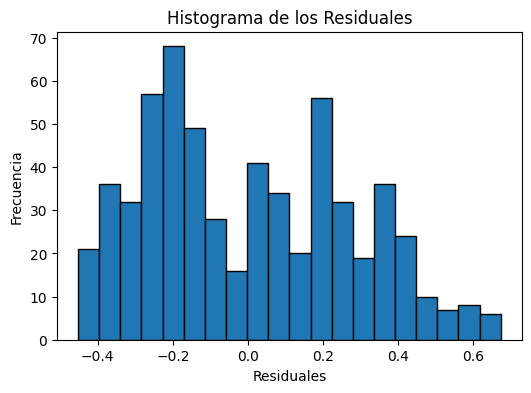

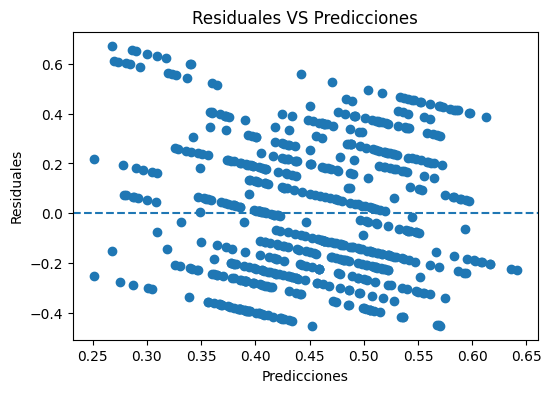

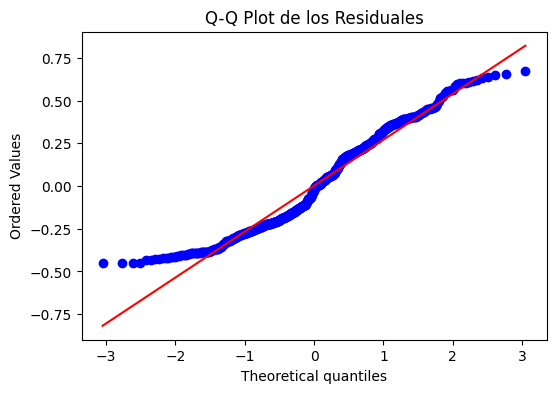

,real,predicho,residual
0,1.000000,0.568953,0.431047
1,0.941176,0.317952,0.623224
2,0.235294,0.419259,-0.183965
3,0.470588,0.251127,0.219461
4,0.352941,0.423027,-0.070085
...,...,...,...
595,0.176471,0.413500,-0.237029
596,0.588235,0.409203,0.179032
597,0.352941,0.522293,-0.169352
598,0.588235,0.391390,0.196845


In [55]:
analisis_residuales(y_test,y_pred_rna)

# 9. Despliegue - Deployment
Construcción del pipeline de implementación

In [56]:
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split

In [57]:
data = pd.read_csv('datos_reg_caso_1.csv')
target = 'Price'

X = data.drop(columns = [target])
y = data[[target]]

In [58]:
#Identificar las variables a ser ignoradas por tipo
all_num = X.select_dtypes(include = ['int64', 'float64']).columns.to_list()
all_cat = X.select_dtypes(include = ['object']).columns.to_list()
ignored = ['Car ID']
num_features = [c for c in all_num if c not in ignored]
cat_features = [c for c in all_cat if c not in ignored]

In [59]:
num_pipe = Pipeline(steps = [('num_imputer', SimpleImputer(strategy = 'constant', fill_value = 0)), ('scaler', MinMaxScaler())])
cat_pipe = Pipeline(steps = [('cat_imputer', SimpleImputer(strategy = 'most_frequent')), ('encoder', OrdinalEncoder())])

In [60]:
num_pipe

Pipeline(steps=[('num_imputer',
                 SimpleImputer(fill_value=0, strategy='constant')),
                ('scaler', MinMaxScaler())])

In [61]:
cat_pipe

Pipeline(steps=[('cat_imputer', SimpleImputer(strategy='most_frequent')),
                ('encoder', OrdinalEncoder())])

In [62]:
reg_8.best_estimator_

GradientBoostingRegressor(criterion='squared_error', loss='absolute_error',
                          max_depth=7, max_leaf_nodes=10, random_state=123)

In [63]:
preprocessor = ColumnTransformer(transformers = [('num', num_pipe, num_features), ('cat', cat_pipe, cat_features)], remainder = 'drop')
model = GradientBoostingRegressor(criterion = 'squared_error', max_depth = 5, n_estimators = 400, random_state = 123)
pipe_model = Pipeline(steps = [('preprocess', preprocessor), ('model', model)])
pipe_model

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('num_imputer',
                                                                   SimpleImputer(fill_value=0,
                                                                                 strategy='constant')),
                                                                  ('scaler',
                                                                   MinMaxScaler())]),
                                                  ['Year', 'Mileage']),
                                                 ('cat',
                                                  Pipeline(steps=[('cat_imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OrdinalEncoder())]),
                                                  ['Brand', 'Model', 'Color',
                                                   'Location'])])),
                ('model',
                 GradientBoostingRegressor(criterion='squared_error',
                                           max_depth=5, n_estimators=400,
                                           random_state=123))])